In [1]:
import os
from typing import Any

import pandas as pd
import numpy as np
import xgboost as xgb
import pandas_ta as ta
import matplotlib.pyplot as plt
from numpy import dtype, ndarray

from utils import download_crypto_data
from datetime import date
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_recall_curve
from numpy.lib.stride_tricks import sliding_window_view
from numba import njit

In [ ]:
download_crypto_data(symbol="BTCUSDT", start=date(2025, 1, 1), end=date(2026, 6, 30), interval="1m", suppress_info=False, tmp_dir="tmp_data")

In [45]:
train_data = pd.read_csv("data/ETHUSDT-5m-2020-01-01_2024-12-31.csv")
test_data = pd.read_csv("data/ETHUSDT-5m-2025-01-01_2026-06-30.csv")
train_df = pd.DataFrame()
test_df = pd.DataFrame()

Feature Engineering

In [46]:
def calculate_rsi(price_array: pd.Series, window=14) -> pd.Series:
    delta = price_array.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/window, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


def calculate_log_interval_ret(price_array: pd.Series, lag1: int, lag2: int) -> np.ndarray:
    # REQUIRE lag1 < lag2
    return np.log(price_array.shift(lag1) / price_array.shift(lag2))


def sigmoid(price_array: pd.Series) -> np.ndarray:
    return np.pow(1 + np.exp(-1 * price_array), -1)


@njit
def rs_one_window(x):
    n = len(x)
    mean = np.mean(x)
    y = np.cumsum(x - mean)
    R = np.max(y) - np.min(y)
    S = np.std(x)
    return R / S if S > 0 else np.nan

@njit
def hurst_rs(series, ns):
    """Compute H for one series given list of scales ns"""
    log_n = np.log(ns.astype(np.float64))
    log_rs = np.empty(len(ns))
    for i, n in enumerate(ns):
        # non-overlapping blocks
        n_blocks = len(series) // n
        if n_blocks < 1:
            log_rs[i] = np.nan
            continue
        rs_vals = np.empty(n_blocks)
        for b in range(n_blocks):
            rs_vals[b] = rs_one_window(series[b*n : (b+1)*n])
        log_rs[i] = np.log(np.nanmean(rs_vals))
    # linear regression slope
    A = np.vstack((log_n, np.ones_like(log_n))).T
    H, _ = np.linalg.lstsq(A, log_rs)[0]
    return H

def rolling_hurst(closes, window=1024, ns=None):
    if ns is None:
        ns = np.array([4, 8, 16, 32, 64])  # good for 5-min data
    total_len = len(closes)
    H = np.full(total_len, np.nan)
    if total_len < window + 1:
        return H
    log_returns = np.log(closes[1: ]) - np.log(closes[ :-1])
    for i in range(window, total_len):
        H[i] = hurst_rs(log_returns[i-window : i], ns)
    return H

def yang_zhang_volatility(df, window=20, trading_periods=252):
    # 1. Calculate the required log-price ratios
    log_ho = np.log(df['High'] / df['Open'])
    log_lo = np.log(df['Low'] / df['Open'])
    log_co = np.log(df['Close'] / df['Open'])

    # Overnight log returns: Open(t) / Close(t-1)
    log_oc = np.log(df['Open'] / df['Close'].shift(1))

    # 2. Compute component variances over the rolling window
    sigma_o_sq = log_oc.rolling(window=window).var()
    sigma_c_sq = log_co.rolling(window=window).var()

    # 3. Compute Rogers-Satchell variance component
    rs_elements = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)
    sigma_rs_sq = rs_elements.rolling(window=window).mean()

    # 4. Dynamically calculate the optimal weight k for the window size n
    k = 0.34 / (1.34 + (window + 1) / (window - 1))

    # 5. Combine components into the final Yang-Zhang variance
    yz_variance = sigma_o_sq + (k * sigma_c_sq) + ((1 - k) * sigma_rs_sq)

    # 6. Return annualized volatility (square root of variance * trading periods)
    return np.sqrt(yz_variance * trading_periods)

In [47]:
t_cost = (0.1 + 0.02 + 0.015) * 0.01  # Transaction cost by Binance + spread + liquidity, or set to zero if wanted
# t_cost = 0

# FEATURE 3: (RELATIVE) MACD + ITS SLOPE
macd_settings = [(12, 48), (24, 48)]
macd_signal = 9
macd_frames_train = [train_df]
macd_frames_test = [test_df]

for fast, slow in macd_settings:
    raw_macd_train = train_data.ta.macd(close='Close', fast=fast, slow=slow, signal=macd_signal).iloc[:, 0]
    rel_macd_train = (raw_macd_train / train_data["Close"]).to_frame()
    col_name = f"FEATURE_MACD_{fast}_{slow}_{macd_signal}"
    rel_macd_train.columns = [col_name]
    slope_col_name = f"FEATURE_MACD_{fast}_{slow}_{macd_signal}_slope"
    rel_macd_train_slope = rel_macd_train.ta.slope(close=rel_macd_train[col_name], length=1).to_frame()
    rel_macd_train_slope.columns = [slope_col_name]
    macd_frames_train.extend([rel_macd_train, rel_macd_train_slope])
    # macd_frames_train.extend([rel_macd_train_slope])

    raw_macd_test = test_data.ta.macd(close='Close', fast=fast, slow=slow, signal=macd_signal).iloc[:, 0]
    rel_macd_test = (raw_macd_test / test_data["Close"]).to_frame()
    rel_macd_test.columns = [col_name]
    rel_macd_test_slope = rel_macd_test.ta.slope(close=rel_macd_test[col_name], length=1).to_frame()
    rel_macd_test_slope.columns = [slope_col_name]
    macd_frames_test.extend([rel_macd_test, rel_macd_test_slope])
    # macd_frames_test.extend([rel_macd_test_slope])

train_df = pd.concat(macd_frames_train, axis=1)
test_df = pd.concat(macd_frames_test, axis=1)

# FEATURE 4: LAGGED RETURNS (+ Kurtosis)
ret_window = [[0, 1]]
kurt_window = [6, 12]
for w in ret_window:
    lag1, lag2 = w[0], w[1]
    train_df[f"FEATURE_LogReturn{lag1}/{lag2}"] = calculate_log_interval_ret(train_data["Close"], lag1, lag2)
    test_df[f"FEATURE_LogReturn{lag1}/{lag2}"] = calculate_log_interval_ret(test_data["Close"], lag1, lag2)
for w in kurt_window:
    train_df[f"FEATURE_ReturnKurt{w}"] = train_data["Close"].pct_change().rolling(window=w, min_periods=w).kurt()
    test_df[f"FEATURE_ReturnKurt{w}"] = test_data["Close"].pct_change().rolling(window=w, min_periods=w).kurt()

# FEATURE 5: MINUTE OF DAY (Cryptos most trade ~10am-2pm EST, EST = UTC-5)
train_data["MinuteNow"] = np.mod(np.floor((train_data["OpenTimestamp[ms]"] - 5 * 3600 * 1000) / (60 * 1000)), 1440)
train_data["CosineMinuteOfDay"] = np.cos(2 * np.pi * train_data["MinuteNow"] / 1440)
train_df["FEATURE_SquaredCosineMinuteOfDay"] = train_data["CosineMinuteOfDay"] * np.abs(train_data["CosineMinuteOfDay"])
test_data["MinuteNow"] = np.mod(np.floor((test_data["OpenTimestamp[ms]"] - 5 * 3600 * 1000) / (60 * 1000)), 1440)
test_data["CosineMinuteOfDay"] = np.cos(2 * np.pi * test_data["MinuteNow"] / 1440)
test_df["FEATURE_SquaredCosineMinuteOfDay"] = test_data["CosineMinuteOfDay"] * np.abs(test_data["CosineMinuteOfDay"])

# FEATURE 6 + 7: Intra-5m volatility (Garman-Klass)
G_K_volat_window = [12]
train_data["Intra5m_G-K_Volatility_Component"] = 0.5 * np.log(train_data["High"] / train_data["Low"]) ** 2 - (2 * np.log(2) - 1) * (np.log(train_data["Close"] / train_data["Open"])) ** 2
test_data["Intra5m_G-K_Volatility_Component"] = 0.5 * np.log(test_data["High"] / test_data["Low"]) ** 2 - (2 * np.log(2) - 1) * (np.log(test_data["Close"] / test_data["Open"])) ** 2
train_data["Intra5m_G-K_Volatility_Component"] = train_data["Intra5m_G-K_Volatility_Component"].replace(0, 1e-10)
test_data["Intra5m_G-K_Volatility_Component"] = test_data["Intra5m_G-K_Volatility_Component"].replace(0, 1e-10)
for w in G_K_volat_window:
    train_mean_w = train_data["Intra5m_G-K_Volatility_Component"].rolling(window=w, min_periods=w).mean()
    train_std_w = train_data["Intra5m_G-K_Volatility_Component"].rolling(window=w, min_periods=w).std()
    test_mean_w = test_data["Intra5m_G-K_Volatility_Component"].rolling(window=w, min_periods=w).mean()
    test_std_w = test_data["Intra5m_G-K_Volatility_Component"].rolling(window=w, min_periods=w).std()

    train_df[f"FEATURE_LogRollingG-KVolatility{w}"] = np.log(train_mean_w)
    train_df[f"FEATURE_RollingG-KVolatilityZscore{w}"] = (train_data["Intra5m_G-K_Volatility_Component"] - train_mean_w) / (train_std_w + 1e-12)
    train_df[f"FEATURE_RollingG-KVolatilitySkew{w}"] = train_data["Intra5m_G-K_Volatility_Component"].rolling(window=w, min_periods=w).skew()
    test_df[f"FEATURE_LogRollingG-KVolatility{w}"] = np.log(test_mean_w)
    test_df[f"FEATURE_RollingG-KVolatilityZscore{w}"] = (test_data["Intra5m_G-K_Volatility_Component"] - test_mean_w) / (test_std_w + 1e-12)
    test_df[f"FEATURE_RollingG-KVolatilitySkew{w}"] = test_data["Intra5m_G-K_Volatility_Component"].rolling(window=w, min_periods=w).skew()

# FEATURE 1: (Close - VWAP) / Volatility
close_window = [3, 6]
train_data["TP"] = (train_data["Open"] + train_data["High"] + train_data["Close"]) / 3
test_data["TP"] = (test_data["Open"] + test_data["High"] + test_data["Close"]) / 3
for w in close_window:
    train_data[f"VWAP{w}"] = (train_data["TP"] * train_data["Volume"]).rolling(window=w, min_periods=w).sum() / train_data["Volume"].rolling(window=w, min_periods=w).sum()
    train_df[f"FEATURE_Close-VWAP/Volatility{w}"] = (train_data["Close"] - train_data[f"VWAP{w}"]) / train_data["Intra5m_G-K_Volatility_Component"]
    test_data[f"VWAP{w}"] = (test_data["TP"] * test_data["Volume"]).rolling(window=w, min_periods=w).sum() / test_data["Volume"].rolling(window=w, min_periods=w).sum()
    test_df[f"FEATURE_Close-VWAP/Volatility{w}"] = (test_data["Close"] - test_data[f"VWAP{w}"]) / test_data["Intra5m_G-K_Volatility_Component"]

# FEATURE 8: ORDER BOOK IMBALANCE
buy_sell_windows = [3, 6]
train_data["TakerSellBaseVolume"] = train_data["Volume"] - train_data["TakerBuyBaseVolume"]
test_data["TakerSellBaseVolume"] = test_data["Volume"] - test_data["TakerBuyBaseVolume"]
train_data["OBIRatio"] = (train_data["TakerBuyBaseVolume"] - train_data["TakerSellBaseVolume"]) / (train_data["TakerBuyBaseVolume"] + train_data["TakerSellBaseVolume"])
test_data["OBIRatio"] = (test_data["TakerBuyBaseVolume"] - test_data["TakerSellBaseVolume"]) / (test_data["TakerBuyBaseVolume"] + test_data["TakerSellBaseVolume"])
for w in buy_sell_windows:
    train_df[f"OBIRatioZscore{w}"] = (train_data["OBIRatio"] - train_data["OBIRatio"].rolling(window=w, min_periods=w).mean()) / train_data["OBIRatio"].rolling(window=w, min_periods=w).std()
    test_df[f"OBIRatioZscore{w}"] = (test_data["OBIRatio"] - test_data["OBIRatio"].rolling(window=w, min_periods=w).mean()) / test_data["OBIRatio"].rolling(window=w, min_periods=w).std()

# # FEATURE 9: HURST EXPONENT (See fractal BM)
# hurst_windows = [64, 128, 256]
# for w in hurst_windows:
#     train_df[f'FEATURE_HurstExponent{w}'] = rolling_hurst(train_data['Close'].values, window=w)
#     test_df[f'FEATURE_HurstExponent{w}'] = rolling_hurst(test_data['Close'].values, window=w)

# FEATURE 10: Yang-Zhang Volatility
trading_periods = int(12 * 24 * 365.25)
Y_Z_volat_window = [3, 6]
for w in Y_Z_volat_window:
    train_df[f"FEATURE_Y-ZVolatility{w}"] = yang_zhang_volatility(train_data, window=w, trading_periods=trading_periods)
    test_df[f"FEATURE_Y-ZVolatility{w}"] = yang_zhang_volatility(test_data, window=w, trading_periods=trading_periods)

Random Matrix Theory

In [ ]:
def rmt_clean_features(df: pd.DataFrame) -> pd.DataFrame:
    # 1. Store metadata and center the original data
    columns = df.columns
    index = df.index
    T, N = df.shape
    X_mean = df.mean()
    X_std = df.std()
    X_standardized = (df - X_mean) / X_std
    # 2. Compute empirical correlation matrix & Eigen-decomposition
    corr = X_standardized.corr()
    eigenvalues, eigenvectors = np.linalg.eigh(corr)
    # 3. Calculate Marcenko-Pastur maximum theoretical boundary (lambda_plus)
    lam = N / T
    max_theoretical_lam = (1 + np.sqrt(lam)) ** 2
    # 4. Filter eigenvalues (Clipping Method)
    noise_indices = eigenvalues <= max_theoretical_lam

    if np.any(noise_indices):
        avg_noise_lam = np.mean(eigenvalues[noise_indices])
        clean_eigenvalues = eigenvalues.copy()
        clean_eigenvalues[noise_indices] = avg_noise_lam
        # 5. Reconstruct the denoised correlation matrix
        clean_corr = eigenvectors @ np.diag(clean_eigenvalues) @ eigenvectors.T
        diag = np.diag(clean_corr)
        clean_corr = clean_corr / np.sqrt(np.outer(diag, diag))

        # 6. Map data back to the clean correlation structure
        try:
            emp_lam, emp_vec = np.linalg.eigh(corr)
            emp_lam = np.maximum(emp_lam, 1e-8)
            inv_sqrt_empirical = emp_vec @ np.diag(1.0 / np.sqrt(emp_lam)) @ emp_vec.T

            clean_lam, clean_vec = np.linalg.eigh(clean_corr)
            clean_lam = np.maximum(clean_lam, 0) # drop tiny negative numerical artifacts
            sqrt_clean = clean_vec @ np.diag(np.sqrt(clean_lam)) @ clean_vec.T

            transform_matrix = inv_sqrt_empirical @ sqrt_clean

            X_cleaned = X_standardized.values @ transform_matrix
            df_cleaned = pd.DataFrame(X_cleaned, index=index, columns=columns)

            return (df_cleaned * X_std) + X_mean

        except np.linalg.LinAlgError:
            print("Linear algebra convergence error. Returning original dataframe.")
            return df

    print("No noise eigenvalues detected below the MP boundary. Returning original dataframe.")
    return df

Add target variable

In [48]:
# train_df = rmt_clean_features(train_df)

# TARGET VARIABLE
train_df[f"TARGET_UpFlag"] = (train_data["Open"] * (1 + t_cost) < train_data["Close"]).shift(-1)
test_df[f"TARGET_UpFlag"] = (test_data["Open"] * (1 + t_cost) < test_data["Close"]).shift(-1)

train_df = train_df.dropna()
test_df = test_df.dropna()
train_df["TARGET_UpFlag"] = train_df["TARGET_UpFlag"].astype(int)
test_df["TARGET_UpFlag"] = test_df["TARGET_UpFlag"].astype(int)

XGBoost Training

In [49]:
# 1. Separate features (X) and target (y)
target_col = "TARGET_UpFlag"
random_state = 648  # Used when fitting XGB Classifier

# Create a chronological validation set from the tail end of your training data
val_size = int(len(train_df) * 0.25)  # val: validation
train_split_df = train_df.iloc[:-val_size]
val_split_df = train_df.iloc[-val_size:]

X_train = train_split_df.drop(columns=[target_col])
y_train = train_split_df[target_col]

X_val = val_split_df.drop(columns=[target_col])
y_val = val_split_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
neg_pos_ratio = num_neg / num_pos
dampened_neg_pos_ratio = (1 + neg_pos_ratio) / 2
sharpened_neg_pos_ratio = neg_pos_ratio * 2

# 2. Initialize XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=3000,           # Max number of trees
    max_depth=3,                 # Decision rules depth
    learning_rate=0.004,
    subsample=0.65,              # Row (Data rows) subsampling
    colsample_bytree=0.4,       # Col (Features) subsampling
    min_child_weight=120,        # Requires at least 120 samples to create a terminal leaf node
    gamma=3.0,
    random_state=random_state,
    eval_metric='aucpr',
    n_jobs=-1,
    early_stopping_rounds=150,   # Stops fitting when no improvement after consecutive 150 rounds
    # scale_pos_weight=neg_pos_ratio,
    reg_alpha=6.5,               # L1 regularization to naturally prune useless features
    reg_lambda=40.0              # L2 regularization to smooth out extreme weight
)

# 3. Train & save the model
# We use the test set as validation to monitor early stopping
print("Training XGBoost model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

os.makedirs("models", exist_ok=True)
model.save_model("models/xgboost_5m_kline.json")

# 4. Evaluate the model
y_pred = model.predict(X_test)
y_val_prob = model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_prob)
beta = 0.5  # Lower values --> More emphasis towards precision
f_scores = ((1 + beta ** 2) * precisions * recalls) / ((beta ** 2 * precisions) + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f_scores[:-1])]
# best_threshold = 0.4

y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred_custom = (y_test_prob >= best_threshold).astype(int)

print(f"\nDynamically Chosen Best Threshold (Max F{beta:.2f}): {best_threshold:.4f}")
print("=== Evaluation Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_custom):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"\nClassification Report [Threshold={best_threshold:.4f}]:")
print(classification_report(y_test, y_test_pred_custom))

# 5. Check Feature Importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
print("\n=== Features Importance ===")
print(importance.nlargest(50))

Training XGBoost model...
[0]	validation_0-aucpr:0.26538
[50]	validation_0-aucpr:0.27686
[100]	validation_0-aucpr:0.27764
[150]	validation_0-aucpr:0.27807
[200]	validation_0-aucpr:0.27818
[250]	validation_0-aucpr:0.27826
[300]	validation_0-aucpr:0.27844
[350]	validation_0-aucpr:0.27860
[400]	validation_0-aucpr:0.27881
[450]	validation_0-aucpr:0.27894
[500]	validation_0-aucpr:0.27904
[550]	validation_0-aucpr:0.27919
[600]	validation_0-aucpr:0.27928
[650]	validation_0-aucpr:0.27939
[700]	validation_0-aucpr:0.27949
[750]	validation_0-aucpr:0.27960
[800]	validation_0-aucpr:0.27969
[850]	validation_0-aucpr:0.27980
[900]	validation_0-aucpr:0.27991
[950]	validation_0-aucpr:0.27999
[1000]	validation_0-aucpr:0.28010
[1050]	validation_0-aucpr:0.28014
[1100]	validation_0-aucpr:0.28020
[1150]	validation_0-aucpr:0.28023
[1200]	validation_0-aucpr:0.28027
[1250]	validation_0-aucpr:0.28031
[1300]	validation_0-aucpr:0.28033
[1350]	validation_0-aucpr:0.28036
[1400]	validation_0-aucpr:0.28041
[1450]	vali

In [50]:
print(np.count_nonzero(y_test_pred_custom))

38670


Plot precision-recall curve

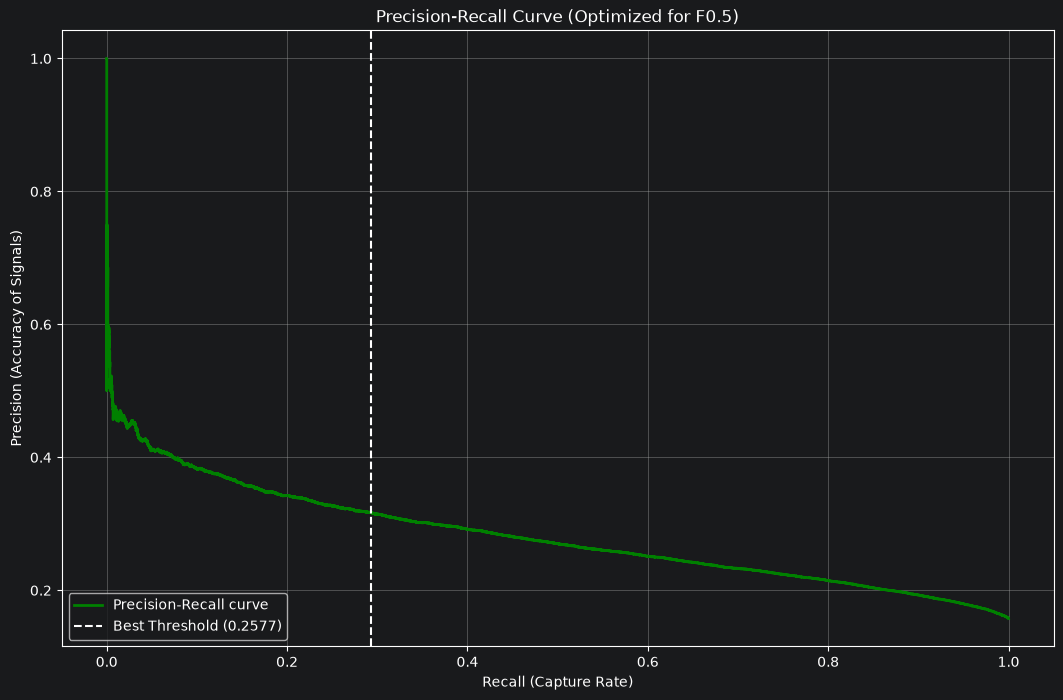

In [38]:
plt.figure(figsize=(12.8, 8.0), dpi=100)
plt.plot(recalls, precisions, label='Precision-Recall curve', color='green', lw=2)
plt.axvline(x=recalls[np.argmax(f_scores[:-1])], color='white', linestyle='--', label=f'Best Threshold ({thresholds[np.argmax(f_scores[:-1])]:.4f})')
plt.xlabel('Recall (Capture Rate)')
plt.ylabel('Precision (Accuracy of Signals)')
plt.title(f'Precision-Recall Curve (Optimized for F{beta})')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()